In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import linregress
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = Path("../data/processed")
CHART_DIR = Path("../reports/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

RF_ANNUAL = 0.065
TRADING_DAYS = 252
RF_DAILY = RF_ANNUAL / TRADING_DAYS


ModuleNotFoundError: No module named 'pandas'

In [2]:
pip install pandas numpy matplotlib seaborn plotly sqlalchemy requests scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 1.5 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 1.4 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 1.1 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 1.3 MB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 829.8 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.1 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [seaborn]2/14 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install jupyter ipykernel

Note: you may need to restart the kernel to use updated packages.


In [ ]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

daily_returns = nav.dropna(subset=["daily_return"]).copy()

print(daily_returns["daily_return"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(daily_returns["daily_return"], bins=100, kde=True)
plt.title("Daily Return Distribution Across All Funds")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(CHART_DIR / "daily_return_distribution.png", dpi=300)
plt.show()


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import linregress
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = Path("../data/processed")
CHART_DIR = Path("../reports/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

RF_ANNUAL = 0.065
TRADING_DAYS = 252
RF_DAILY = RF_ANNUAL / TRADING_DAYS


In [5]:
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master_clean.csv")
nav = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv")
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")
benchmark = pd.read_csv(PROCESSED_DIR / "10_benchmark_indices_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav.shape)
print(benchmark["index_name"].unique())


FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/01_fund_master_clean.csv'

In [6]:
from pathlib import Path

BASE_DIR = Path("/Users/dhanistha/mutual-fund-analytics")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
CHART_DIR = BASE_DIR / "reports" / "charts"

CHART_DIR.mkdir(parents=True, exist_ok=True)

print(PROCESSED_DIR)
print(list(PROCESSED_DIR.glob("*.csv")))


/Users/dhanistha/mutual-fund-analytics/data/processed
[PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/03_aum_by_fund_house_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/02_nav_history_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/08_investor_transactions_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/10_benchmark_indices_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/05_category_inflows_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/07_scheme_performance_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/09_portfolio_holdings_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/04_monthly_sip_inflows_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/processed/01_fund_master_clean.csv'), PosixPath('/Users/dhanistha/mutual-fund-analytics/data/proc

In [7]:
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master_clean.csv")
nav = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv")
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")
benchmark = pd.read_csv(PROCESSED_DIR / "10_benchmark_indices_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav.shape)
print(benchmark["index_name"].unique())


(64320, 3)
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


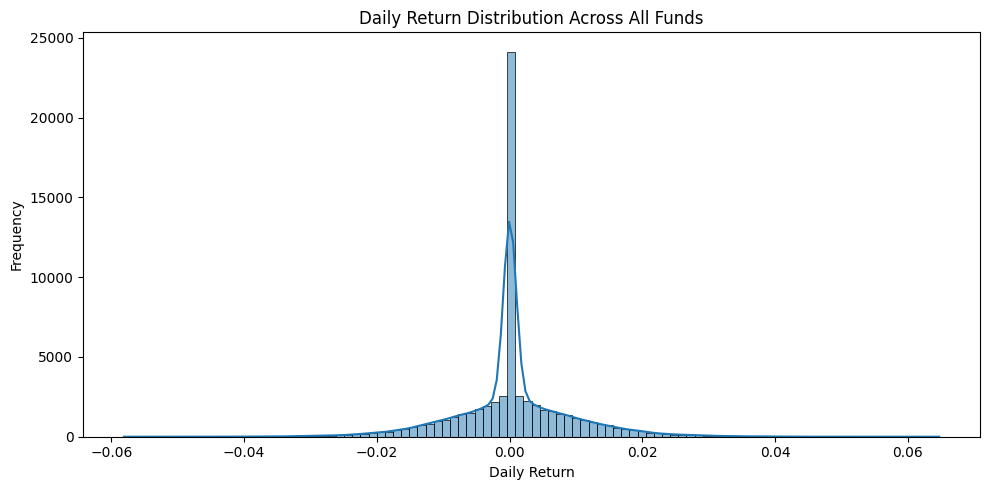

In [8]:
 nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

daily_returns = nav.dropna(subset=["daily_return"]).copy()

print(daily_returns["daily_return"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(daily_returns["daily_return"], bins=100, kde=True)
plt.title("Daily Return Distribution Across All Funds")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(CHART_DIR / "daily_return_distribution.png", dpi=300)
plt.show()


In [9]:
def calculate_cagr(group, years):
    group = group.sort_values("date")
    end_date = group["date"].max()
    start_target = end_date - pd.DateOffset(years=years)

    start_rows = group[group["date"] >= start_target]
    if start_rows.empty:
        return np.nan

    start_nav = start_rows.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    if start_nav <= 0 or end_nav <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / years)) - 1


cagr_rows = []

for amfi_code, group in nav.groupby("amfi_code"):
    cagr_rows.append({
        "amfi_code": amfi_code,
        "cagr_1yr": calculate_cagr(group, 1),
        "cagr_3yr": calculate_cagr(group, 3),
        "cagr_5yr": calculate_cagr(group, 5),
    })

cagr_table = pd.DataFrame(cagr_rows)

cagr_table = cagr_table.merge(
    fund_master[["amfi_code", "fund_house", "scheme_name", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

cagr_table.head()


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,fund_house,scheme_name,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100025,0.037050,0.039164,0.039127,HDFC Mutual Fund,HDFC Short Term Debt Fund - Regular - Growth,0.56
2,100033,0.532324,0.324425,0.260741,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38
3,101206,0.479241,0.289677,0.204427,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,1.60
4,101207,-0.239860,-0.041524,0.069533,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,1.53


In [10]:
risk_rows = []

for amfi_code, group in daily_returns.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    excess_returns = returns - RF_DAILY

    sharpe = np.nan
    sortino = np.nan

    if returns.std() != 0:
        sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS)

    downside_returns = returns[returns < 0]

    if downside_returns.std() != 0:
        sortino = (excess_returns.mean() / downside_returns.std()) * np.sqrt(TRADING_DAYS)

    risk_rows.append({
        "amfi_code": amfi_code,
        "avg_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
    })

risk_metrics = pd.DataFrame(risk_rows)

risk_metrics = risk_metrics.merge(
    fund_master[["amfi_code", "fund_house", "scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_metrics.sort_values("sharpe_ratio", ascending=False).head(10)


,amfi_code,avg_daily_return,daily_volatility,sharpe_ratio,sortino_ratio,fund_house,scheme_name
34,148567,0.000768,0.007575,1.068224,1.490739,Mirae Asset MF,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.000773,0.008475,0.965561,1.479503,Kotak Mahindra MF,Kotak Flexicap Fund - Regular - Growth
36,148569,0.000804,0.009427,0.919047,1.352815,Mirae Asset MF,Mirae Asset Tax Saver Fund - Regular - Growth
25,120505,0.000830,0.010288,0.883256,1.285843,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.000656,0.007330,0.860977,1.291483,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth
38,149323,0.000754,0.009464,0.832885,1.167793,DSP Mutual Fund,DSP Midcap Fund - Regular - Growth
2,100033,0.000772,0.010097,0.808268,1.144216,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.000619,0.007545,0.758851,1.098880,Nippon India MF,Nippon India Large Cap Fund - Regular - Growth
16,119094,0.000734,0.010347,0.730547,1.055284,Axis Mutual Fund,Axis Midcap Fund - Regular - Growth
3,101206,0.000609,0.007768,0.717409,1.063909,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth


In [11]:
benchmark_pivot = benchmark.pivot_table(
    index="date",
    columns="index_name",
    values="close_value"
).sort_index()

benchmark_returns = benchmark_pivot.pct_change().dropna()

nifty100_col = [col for col in benchmark_returns.columns if "100" in col.upper()][0]

alpha_beta_rows = []

for amfi_code, group in daily_returns.groupby("amfi_code"):
    fund_ret = group.set_index("date")["daily_return"]

    combined = pd.concat(
        [fund_ret, benchmark_returns[nifty100_col]],
        axis=1,
        join="inner"
    ).dropna()

    combined.columns = ["fund_return", "benchmark_return"]

    if len(combined) < 30:
        alpha = np.nan
        beta = np.nan
        r_value = np.nan
    else:
        regression = linregress(
            combined["benchmark_return"],
            combined["fund_return"]
        )

        beta = regression.slope
        alpha = regression.intercept * TRADING_DAYS
        r_value = regression.rvalue

    alpha_beta_rows.append({
        "amfi_code": amfi_code,
        "benchmark": nifty100_col,
        "alpha_annual": alpha,
        "beta": beta,
        "r_squared": r_value ** 2 if pd.notna(r_value) else np.nan,
    })

alpha_beta = pd.DataFrame(alpha_beta_rows)

alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "fund_house", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.to_csv(PROCESSED_DIR / "alpha_beta.csv", index=False)

alpha_beta.sort_values("alpha_annual", ascending=False).head()


,amfi_code,benchmark,alpha_annual,beta,r_squared,fund_house,scheme_name
21,119598,NIFTY100,0.303370,-0.023196,1.414258e-04,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth
39,149324,NIFTY100,0.300579,0.011455,3.532991e-05,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth
25,120505,NIFTY100,0.292636,0.000549,1.345534e-07,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth
36,148569,NIFTY100,0.282704,0.018134,1.748889e-04,Mirae Asset MF,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,NIFTY100,0.273305,-0.022830,3.430543e-04,Kotak Mahindra MF,Kotak Flexicap Fund - Regular - Growth


In [12]:
drawdown_rows = []

for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    max_dd_row = group.loc[group["drawdown"].idxmin()]
    trough_date = max_dd_row["date"]
    max_drawdown = max_dd_row["drawdown"]

    peak_date = group[group["date"] <= trough_date].loc[
        group[group["date"] <= trough_date]["nav"].idxmax(), "date"
    ]

    drawdown_rows.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "drawdown_peak_date": peak_date,
        "drawdown_trough_date": trough_date,
    })

drawdown_metrics = pd.DataFrame(drawdown_rows)

drawdown_metrics = drawdown_metrics.merge(
    fund_master[["amfi_code", "fund_house", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdown_metrics.sort_values("max_drawdown").head(10)


,amfi_code,max_drawdown,drawdown_peak_date,drawdown_trough_date,fund_house,scheme_name
22,119599,-0.525742,2023-01-17,2025-10-28,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2025-05-22,2026-05-11,Axis Mutual Fund,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2024-11-21,2026-05-11,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2024-05-03,2025-01-03,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2024-08-28,2025-05-14,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2025-01-07,2026-04-27,UTI Mutual Fund,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-03-30,2022-09-15,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2023-11-09,2024-10-17,Kotak Mahindra MF,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2025-04-09,2026-02-20,Nippon India MF,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2022-02-24,2023-05-22,Axis Mutual Fund,Axis Bluechip Fund - Direct - Growth


In [13]:
scorecard = (
    cagr_table
    .merge(risk_metrics[["amfi_code", "sharpe_ratio", "sortino_ratio"]], on="amfi_code", how="left")
    .merge(alpha_beta[["amfi_code", "alpha_annual", "beta"]], on="amfi_code", how="left")
    .merge(drawdown_metrics[["amfi_code", "max_drawdown", "drawdown_peak_date", "drawdown_trough_date"]], on="amfi_code", how="left")
)

scorecard["return_rank_score"] = scorecard["cagr_3yr"].rank(pct=True) * 100
scorecard["sharpe_rank_score"] = scorecard["sharpe_ratio"].rank(pct=True) * 100
scorecard["alpha_rank_score"] = scorecard["alpha_annual"].rank(pct=True) * 100

scorecard["expense_rank_score"] = scorecard["expense_ratio_pct"].rank(
    pct=True,
    ascending=False
) * 100

scorecard["drawdown_rank_score"] = scorecard["max_drawdown"].rank(
    pct=True,
    ascending=True
) * 100

scorecard["fund_score"] = (
    0.30 * scorecard["return_rank_score"] +
    0.25 * scorecard["sharpe_rank_score"] +
    0.20 * scorecard["alpha_rank_score"] +
    0.15 * scorecard["expense_rank_score"] +
    0.10 * scorecard["drawdown_rank_score"]
)

scorecard = scorecard.sort_values("fund_score", ascending=False)

scorecard.to_csv(PROCESSED_DIR / "fund_scorecard.csv", index=False)

scorecard.head(10)


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,fund_house,scheme_name,expense_ratio_pct,sharpe_ratio,sortino_ratio,alpha_annual,beta,max_drawdown,drawdown_peak_date,drawdown_trough_date,return_rank_score,sharpe_rank_score,alpha_rank_score,expense_rank_score,drawdown_rank_score,fund_score
34,148567,0.203607,0.340009,0.267993,Mirae Asset MF,Mirae Asset Large Cap Fund - Regular - Growth,1.46,1.068224,1.490739,0.269838,0.023684,-0.112657,2023-07-11,2023-10-20,97.5,100.0,85.0,45.00,82.5,86.2500
25,120505,0.296047,0.317775,0.283768,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth,1.36,0.883256,1.285843,0.292636,0.000549,-0.181885,2024-10-24,2025-01-23,90.0,92.5,95.0,65.00,40.0,82.8750
30,120843,0.266571,0.295828,0.267425,Kotak Mahindra MF,Kotak Flexicap Fund - Regular - Growth,1.45,0.965561,1.479503,0.273305,-0.022830,-0.129740,2022-03-07,2022-04-13,85.0,97.5,90.0,47.50,70.0,82.0000
2,100033,0.532324,0.324425,0.260741,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,0.808268,1.144216,0.271954,0.005104,-0.162172,2022-03-11,2022-05-12,92.5,85.0,87.5,60.00,52.5,80.7500
24,120504,0.130643,0.324874,0.202340,ICICI Prudential MF,ICICI Pru Bluechip Fund - Direct - Growth,0.80,0.714682,1.063964,0.211948,0.016232,-0.125883,2022-10-04,2023-05-30,95.0,75.0,70.0,72.50,72.5,79.3750
16,119094,0.222611,0.351118,0.244453,Axis Mutual Fund,Axis Midcap Fund - Regular - Growth,1.38,0.730547,1.055284,0.260767,-0.066265,-0.209609,2022-04-14,2022-08-11,100.0,80.0,80.0,60.00,32.5,78.2500
19,119551,0.604373,0.304565,0.223849,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,1.54,0.860977,1.291483,0.232010,-0.031751,-0.150124,2023-08-24,2024-02-05,87.5,90.0,77.5,26.25,60.0,74.1875
36,148569,0.397518,0.291789,0.276299,Mirae Asset MF,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,0.919047,1.352815,0.282704,0.018134,-0.163967,2023-08-10,2023-10-20,82.5,95.0,92.5,11.25,50.0,73.6875
21,119598,0.827761,0.266699,0.280332,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,1.43,0.711690,1.067256,0.303370,-0.023196,-0.287060,2024-08-28,2025-05-14,72.5,70.0,100.0,50.00,12.5,68.0000
3,101206,0.479241,0.289677,0.204427,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,1.60,0.717409,1.063909,0.213998,0.021086,-0.112916,2023-04-24,2023-07-05,80.0,77.5,72.5,11.25,80.0,67.5625


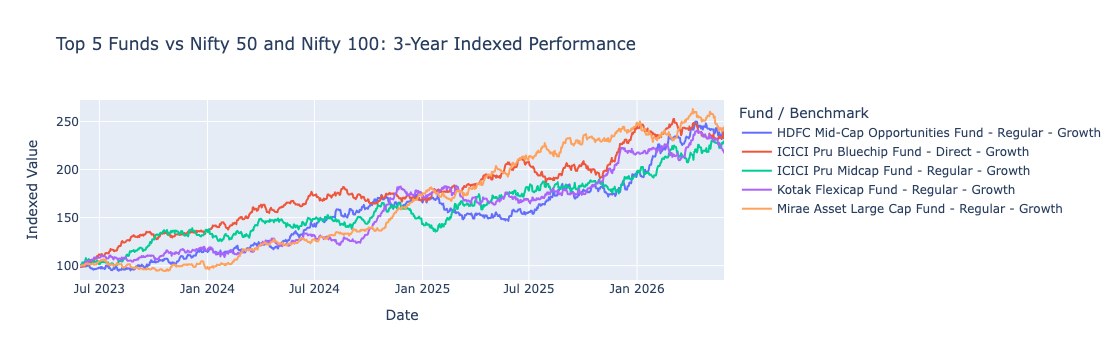

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [14]:
top_5_codes = scorecard.head(5)["amfi_code"].tolist()

nifty_cols = [col for col in benchmark_pivot.columns if "NIFTY 50" in col.upper() or "NIFTY 100" in col.upper()]

fund_nav = nav[nav["amfi_code"].isin(top_5_codes)].merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

latest_date = fund_nav["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

fund_nav_3yr = fund_nav[fund_nav["date"] >= start_date].copy()

fund_pivot = fund_nav_3yr.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
).sort_index()

benchmark_3yr = benchmark_pivot[nifty_cols]
benchmark_3yr = benchmark_3yr[benchmark_3yr.index >= start_date]

comparison = pd.concat([fund_pivot, benchmark_3yr], axis=1).dropna(how="all")
comparison_indexed = comparison / comparison.iloc[0] * 100

fig = px.line(
    comparison_indexed,
    x=comparison_indexed.index,
    y=comparison_indexed.columns,
    title="Top 5 Funds vs Nifty 50 and Nifty 100: 3-Year Indexed Performance",
    labels={"value": "Indexed Value", "date": "Date", "variable": "Fund / Benchmark"}
)

fig.show()
fig.write_image(CHART_DIR / "benchmark_comparison_top5.png")


In [15]:
fund_returns_3yr = fund_pivot.pct_change()
benchmark_returns_3yr = benchmark_3yr.pct_change()

tracking_rows = []

for fund in fund_returns_3yr.columns:
    for bench in benchmark_returns_3yr.columns:
        combined = pd.concat(
            [fund_returns_3yr[fund], benchmark_returns_3yr[bench]],
            axis=1,
            join="inner"
        ).dropna()

        combined.columns = ["fund_return", "benchmark_return"]

        tracking_error = (
            (combined["fund_return"] - combined["benchmark_return"]).std()
            * np.sqrt(TRADING_DAYS)
        )

        tracking_rows.append({
            "fund": fund,
            "benchmark": bench,
            "tracking_error": tracking_error
        })

tracking_error = pd.DataFrame(tracking_rows)
tracking_error


""


In [16]:
tracking_error.to_csv(PROCESSED_DIR / "tracking_error.csv", index=False)


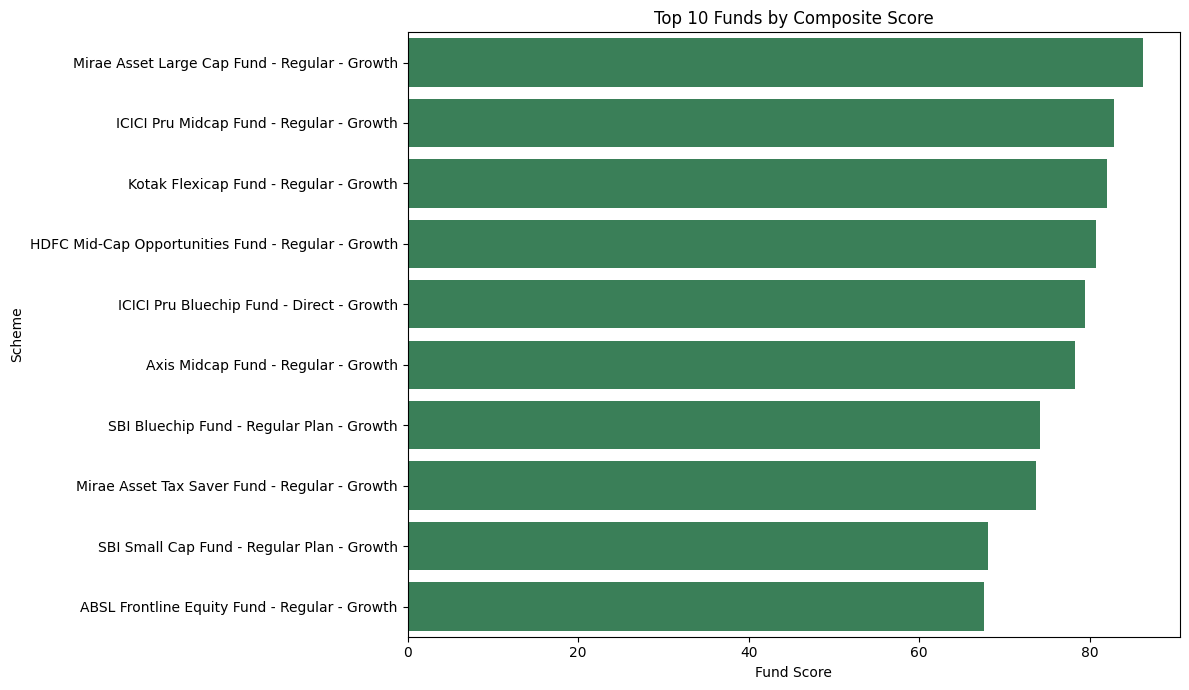

In [17]:
top_scorecard = scorecard.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_scorecard,
    y="scheme_name",
    x="fund_score",
    color="seagreen"
)

plt.title("Top 10 Funds by Composite Score")
plt.xlabel("Fund Score")
plt.ylabel("Scheme")
plt.tight_layout()
plt.savefig(CHART_DIR / "fund_scorecard_top10.png", dpi=300)
plt.show()


In [18]:
ls data/processed
ls reports/charts



SyntaxError: invalid syntax (3735083627.py, line 1)

In [19]:
ls data/processed


01_fund_master_clean.csv            08_investor_transactions_clean.csv
02_nav_history_clean.csv            09_portfolio_holdings_clean.csv
03_aum_by_fund_house_clean.csv      10_benchmark_indices_clean.csv
04_monthly_sip_inflows_clean.csv    alpha_beta.csv
05_category_inflows_clean.csv       fund_scorecard.csv
06_industry_folio_count_clean.csv   tracking_error.csv
07_scheme_performance_clean.csv


In [20]:
ls reports/charts


02_aum_growth_by_fund_house.png    09_city_tier_split.png
04_category_inflow_heatmap.png     11_nav_return_correlation.png
05_age_group_distribution.png      13_top_funds_5yr_return.png
06_sip_amount_by_age_group.png     14_expense_ratio_distribution.png
07_gender_split.png                daily_return_distribution.png
08_sip_amount_by_state.png         fund_scorecard_top10.png
